# Climate Change Signal — DestinE Generation 2

Compare **30-year mean 2m temperature between historical and scenario experiments** across IFS-FESOM, IFS-NEMO, and ICON using monthly (`clmn`) data from the DestinE Climate DT Generation 2 simulations.

In [1]:
from destine_climate_helpers import fetch_period
import healpy as hp
import matplotlib.pyplot as plt

earthkit-data cache: trying to free 4.6 GiB
earthkit-data cache: could not free 4.6 GiB
earthkit-data cache: trying to free 4.6 GiB
earthkit-data cache: could not free 4.6 GiB


In [2]:
# --- Configuration ---
PARAM = 'avg_2t'
PARAM_NAME = '2m Temperature'
MODELS = ['IFS-NEMO','IFS-FESOM'] # ['IFS-NEMO','IFS-FESOM','ICON']
RESOLUTION = 'standard'
STORE_DATA = True          # Set True to cache NetCDF files to DATA_DIR
DATA_DIR = './data'

# Historical period
HIST_YEARS = range(1990, 2015)
HIST_EXPERIMENT = 'hist'        # activity: baseline

# Future period
SCEN_YEARS = range(2015, 2050)
SCEN_EXPERIMENT = 'SSP3-7.0'   # activity: projections

In [3]:
# Download monthly data for all models and both periods
data = {}
for model in MODELS:
    print(f'\n=== {model} ===')
    
    print(f'Fetching {HIST_EXPERIMENT} ({HIST_YEARS[0]}-{HIST_YEARS[-1]})...')
    hist = fetch_period(model, HIST_EXPERIMENT, HIST_YEARS, PARAM, RESOLUTION, STORE_DATA, DATA_DIR)
    
    print(f'Fetching {SCEN_EXPERIMENT} ({SCEN_YEARS[0]}-{SCEN_YEARS[-1]})...')
    scen = fetch_period(model, SCEN_EXPERIMENT, SCEN_YEARS, PARAM, RESOLUTION, STORE_DATA, DATA_DIR)
    
    data[model] = {'hist': hist, 'scen': scen}


=== IFS-NEMO ===
Fetching hist (1990-2014)...
  IFS-NEMO hist 1990-2014: downloading (25 years in one request)...


2026-03-19 13:20:21 - INFO - Key read from /Users/natr/.polytopeapirc
2026-03-19 13:20:21 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: IFS-NEMO\n'
            'month: 1/2/3/4/5/6/7/8/9/10/11/12\n'
            'param: avg_2t\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clmn\n'
            'type: fc\n'
            'year: '
            '1990/1991/1992/1993/1994/1995/1996/1997/1998/1999/2000/2001/2002/2003/2004/2005/2006/2007/2008/2009/2010/2011/2012/2013/2014\n',
 'verb': 'retrieve'}
2026-03-19 13:20:21 - INFO - Polytope user key found in session cache for user natr
2026-03-19 13:20:22 - INFO - Request accepted. Please poll ./38b853f6-1277-4987-8187-0ccf08e534ce for status
2026-03-19 13:20:22 - INFO - Polytope user key 

Fetching SSP3-7.0 (2015-2049)...
  IFS-NEMO SSP3-7.0 2015-2049: downloading (35 years in one request)...


2026-03-19 13:20:43 - INFO - Request accepted. Please poll ./c2897fcb-61c8-47b4-98a2-79df9baf39b7 for status
2026-03-19 13:20:43 - INFO - Polytope user key found in session cache for user natr
2026-03-19 13:20:43 - INFO - Checking request status (c2897fcb-61c8-47b4-98a2-79df9baf39b7)...
2026-03-19 13:20:43 - INFO - The current status of the request is 'queued'
2026-03-19 13:20:44 - INFO - The current status of the request is 'processing'
2026-03-19 13:20:47 - INFO - The current status of the request is 'processed'
earthkit-data cache: trying to free 9.2 GiB                                                   
Deleting entry {
    "path": "/var/folders/15/7p6jc6_n541_jhsksg9740h80000gn/T/tmpvq8ce9gv/polytope-b3b8a8a4cc0be878227f3e4f29dbde379c5bbc9837a12b605a39c22232dbc26a.cache",
    "owner": "polytope",
    "args": [
        "destination-earth",
        {
            "class": "d1",
            "dataset": "climate-dt",
            "type": "fc",
            "expver": "0001",
            "g


=== IFS-FESOM ===
Fetching hist (1990-2014)...
  IFS-FESOM hist 1990-2014: downloading (25 years in one request)...


2026-03-19 13:20:57 - INFO - Request accepted. Please poll ./6e28bb38-9549-4eeb-a4bf-575196e4e0ce for status
2026-03-19 13:20:57 - INFO - Polytope user key found in session cache for user natr
2026-03-19 13:20:57 - INFO - Checking request status (6e28bb38-9549-4eeb-a4bf-575196e4e0ce)...
2026-03-19 13:20:58 - INFO - The current status of the request is 'queued'
2026-03-19 13:21:26 - INFO - The current status of the request is 'processing'
2026-03-19 13:21:30 - INFO - The current status of the request is 'processed'
earthkit-data cache: trying to free 9.2 GiB                                                   
Deleting entry {
    "path": "/var/folders/15/7p6jc6_n541_jhsksg9740h80000gn/T/tmpvq8ce9gv/polytope-771fe13330361b6ee993db3846470af5ac54840caacf9a1ab797781a7111d0a2.cache",
    "owner": "polytope",
    "args": [
        "destination-earth",
        {
            "class": "d1",
            "dataset": "climate-dt",
            "type": "fc",
            "expver": "0001",
            "g

Fetching SSP3-7.0 (2015-2049)...
  IFS-FESOM SSP3-7.0 2015-2049: downloading (35 years in one request)...


2026-03-19 13:21:43 - INFO - Request accepted. Please poll ./c0727e08-8017-4cec-a870-281cd05622b4 for status
2026-03-19 13:21:43 - INFO - Polytope user key found in session cache for user natr
2026-03-19 13:21:43 - INFO - Checking request status (c0727e08-8017-4cec-a870-281cd05622b4)...
2026-03-19 13:21:44 - INFO - The current status of the request is 'queued'
2026-03-19 13:22:20 - INFO - The current status of the request is 'processing'
2026-03-19 13:22:23 - INFO - The current status of the request is 'processed'
earthkit-data cache: trying to free 9.2 GiB                                                   
Deleting entry {
    "path": "/var/folders/15/7p6jc6_n541_jhsksg9740h80000gn/T/tmpvq8ce9gv/polytope-a91a27eb4ac43c2f28d651aabbdfdd73f4cd4768ed2caaf74127817cb3f66122.cache",
    "owner": "polytope",
    "args": [
        "destination-earth",
        {
            "class": "d1",
            "dataset": "climate-dt",
            "type": "fc",
            "expver": "0001",
            "g

- **The resulting data is cached in the following folder structure** if you have set `STORE_DATA = True`

In [4]:
!ls data/{ICON,IFS-FESOM,IFS-NEMO}/{hist,SSP*}/clmn/standard/*nc | head -20

zsh:1: no matches found: data/ICON/hist/clmn/standard/*nc


- **Your data is stored in an `xarray.DataArray`**, grouped by model name and experiment

In [5]:
data['IFS-NEMO']['hist'] # ICON/IFS-NEMO/IFS-FESOM + hist/scen

<xarray.DataArray 'avg_2t' (valid_time: 300, values: 196608)> Size: 472MB
array([[300.35387421, 300.32045746, 300.37814331, ..., 300.28879547,
        300.33238983, 300.28031158],
       [300.63121033, 300.62636566, 300.60066223, ..., 300.78045654,
        300.8534317 , 300.80496216],
       [301.14697266, 301.17009735, 301.16251373, ..., 300.87689972,
        300.89194489, 300.86269379],
       ...,
       [300.21492004, 300.20041656, 300.18138885, ..., 300.52954865,
        300.58959961, 300.56774902],
       [300.79515076, 300.62775421, 300.69081116, ..., 300.70371246,
        300.76372528, 300.73851013],
       [300.43686676, 300.41079712, 300.43910217, ..., 300.80509949,
        300.8688736 , 300.82019043]], shape=(300, 196608))
Coordinates:
  * valid_time  (valid_time) <U19 23kB '1990-02-01T00:00:00' ... '2015-01-01T...
    latitude    (values) float64 2MB 0.2984 0.5968 0.5968 ... -0.5968 -0.2984
    longitude   (values) float64 2MB 45.0 45.35 44.65 45.0 ... 315.4 314.6 315.0
Dimensions without coordinates: values
Attributes:
    standard_name:  air_temperature
    long_name:      Time-mean 2 metre temperature
    units:          K
    _earthkit:      {'message': b'GRIB\xff\xff\x00\x02\x00\x00\x00\x00\x00\x0...
    valid_time:     1990-02-01T00:00:00

In [6]:
# Compute climate change signal: future mean minus historical mean
diffs = {}
for model in MODELS:
    hist_mean = data[model]['hist'].mean(dim='valid_time')
    scen_mean = data[model]['scen'].mean(dim='valid_time')
    diffs[model] = scen_mean - hist_mean

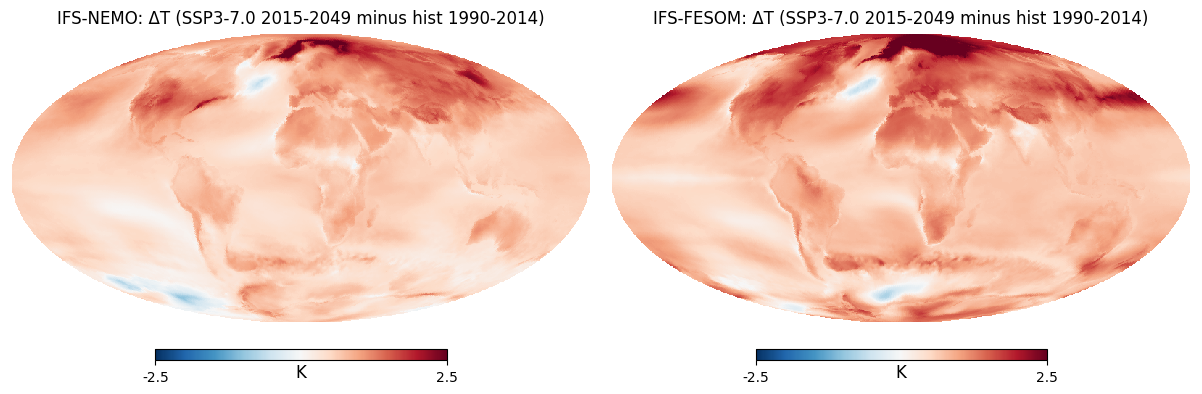

In [7]:
# Plot climate change signal for each model
vmin = -2.5
vmax = 2.5

fig = plt.figure(figsize=(18, 5))
for i, model in enumerate(MODELS):
    hp.mollview(
        diffs[model].values, nest=True, flip='geo',
        cmap='RdBu_r', min=vmin, max=vmax,
        title=f'{model}: \u0394T ({SCEN_EXPERIMENT} {SCEN_YEARS[0]}-{SCEN_YEARS[-1]}'
              f' minus {HIST_EXPERIMENT} {HIST_YEARS[0]}-{HIST_YEARS[-1]})',
        unit='K', sub=(1, 3, i + 1),
    )

In [8]:
# Global mean temperature change per model
# (HEALPix pixels are equal-area, so a simple mean is area-weighted)
for model in MODELS:
    print(f'{model}: global mean \u0394T = {float(diffs[model].mean()):.2f} K')

IFS-NEMO: global mean ΔT = 0.65 K
IFS-FESOM: global mean ΔT = 0.85 K


## How to extend this notebook for your analysis

- **Change variable**: set `PARAM` to another code (e.g. `'235043'` for total precipitation), update `PARAM_NAME`
- **Seasonal breakdown**: after computing `diffs`, you can group by month using `xarray.groupby('valid_time.season')`
- **Different scenario**: change `SCEN_EXPERIMENT` (e.g. another SSP once available)
- **Store data locally**: set `STORE_DATA = True` and adjust `DATA_DIR`; subsequent runs will then load from cache